## Synthetic example for the MESA paper.
#### Objective: Showcase the effects of changes in the different STFT parameters. 

In [46]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy
import mesa

### Build the signal

In [47]:
sr = 800 # Hz
duration = 3.0 # s
N = int(sr*duration)
x = np.linspace(0, duration, N)

y1 = 10*np.cos(2*np.pi*15.0*x[0:N//3]) # Mono-mode signal
y2 = 5*np.cos(2*np.pi*10.0*x[N//3:N//3*2]) + 8*np.cos(2*np.pi*20.0*x[N//3:N//3*2]) # Bi-modal signal
y3 = 7*scipy.signal.chirp(x[0:N//3], f0=5.0, t1=duration//3, f1=50.0)

y = np.append(y1, y2, axis = 0)
y = np.append(y,  y3, axis = 0)


In [48]:
# STFT params
window_length = int(.75*sr)
hop = window_length//40
window = "blackman"
n_bins = window_length
center = True

In [49]:
from mesa.features import stft

D = stft(y,window_length,hop, center=center)
Sxx = np.abs(D)**2

(0.0, 3.0)

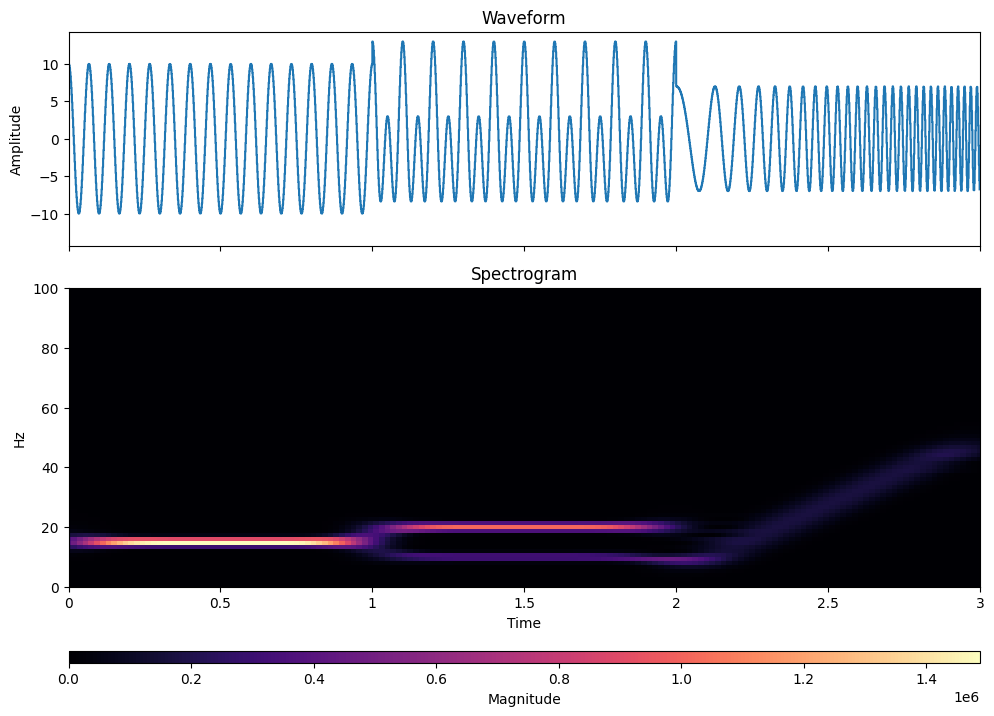

In [50]:
from mesa.visualization import spectrogram, dual_plot

fig = dual_plot(y, Sxx, sr, window_length, hop, center = center);
ax = fig.get_axes()
ax[1].set_ylim(0,100)
ax[1].set_xlim(0,3)